# Reporduce graphs for the papaer

This notebook reproduces the clustering analysis from `Pricescraper/6_analysis/cluster_market_personalities.py` and displays all figures inline. It also writes the same outputs to `reports/figures/cluster_market_personalities/` for record keeping.


In [1]:
# Imports and module loader
import sys
from pathlib import Path
from IPython.display import display, Image, Markdown

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# # Pretty plots
# plt.style.use('seaborn-v0_8')
# sns.set_palette("husl")

# Load analysis module by path (no package needed)
import importlib.util

# Notebook is in the same folder as the module
module_path = Path('cluster_market_personalities.py')
spec = importlib.util.spec_from_file_location('cluster_market_personalities', str(module_path))
cmp = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cmp)

# Output directory used by the script
figures_dir = Path('reports/figures/cluster_market_personalities')
figures_dir.mkdir(parents=True, exist_ok=True)

figures_dir


WindowsPath('reports/figures/cluster_market_personalities')

In [2]:
# Load data
import os
from pathlib import Path

# Ensure working directory is the project root so relative data paths work
needed = Path('data/processed/filtered_hplib_w_prices_and_decoding.csv')
if not needed.exists():
    # Walk up to 6 levels to find the repo root containing 'data/processed/...'
    cur = Path.cwd()
    for _ in range(6):
        candidate = cur / needed
        if candidate.exists():
            os.chdir(cur)
            break
        cur = cur.parent

df = cmp.load_data()
display(df.head())
print(f"Loaded {len(df)} rows and {df.shape[1]} columns")


,Manufacturer,Model,Titel,Date,Model/Type,Price,Currency,Website,Date_scraped,Type,...,eta medium T [%],SCOP,SEER low T,SEER medium T,P_th_h_ref [W],P_th_c_ref [W],P_el_h_ref [W],P_el_c_ref [W],COP_ref,EER_c_ref
0,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS6800iAW 7 ORE-S,30.03.2023,Bosch Set BOPA CS772 AW 7 OR-S CS6800iAW 12 E ...,9933.0,EUR,idealo,2025-03-14,Outdoor Air/Water,...,138.0,4.58,NaN,NaN,5940.0,NaN,2842.0,NaN,2.09,NaN
1,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORM-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS761 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,...,127.0,4.55,NaN,NaN,3510.0,NaN,1671.0,NaN,2.10,NaN
2,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 5 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS774 AW 5 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,...,136.0,4.55,NaN,NaN,5530.0,NaN,2646.0,NaN,2.09,NaN
3,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 4 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS776 AW 4 OR...,10999.0,€,raleo,2025-03-12,Outdoor Air/Water,...,128.0,4.55,NaN,NaN,3530.0,NaN,1673.0,NaN,2.11,NaN
4,Bosch Thermotechnik GmbH,Bosch CS5800i/6800iAW 4/5/7 OR,CS5800iAW 7 ORMB-S,30.03.2023,BOSCH Luftwärmepumpen-Paket BOPA CS775 AW 7 OR...,11499.0,€,raleo,2025-03-12,Outdoor Air/Water,...,136.0,4.56,NaN,NaN,5980.0,NaN,2917.0,NaN,2.05,NaN


Loaded 696 rows and 43 columns


In [3]:
# Prepare clustering data

feature_df, df_aligned = cmp.prepare_clustering_data(df)
print(f"Final dataset: {len(feature_df)} products with {len(feature_df.columns)} features")
display(feature_df.describe())


Preparing data for clustering analysis...
Dataset after cleaning: 696 records
Final dataset: 696 products with 5 features
Clustering features:
  - SCOP: 3.84 to 5.45
  - Noise_dBA: 40.00 to 69.00
  - Price_per_kW: 330.00 to 2795.23
  - Max_Temp_C: 35.00 to 78.00
  - Rated_Power_kW: 3.44 to 13.00
Final dataset: 696 products with 5 features


,SCOP,Noise_dBA,Price_per_kW,Max_Temp_C,Rated_Power_kW
count,696.000000,696.000000,696.000000,696.000000,696.000000
mean,4.720905,54.647989,1135.937695,59.369253,8.251121
std,0.237698,6.694006,386.069386,12.519803,2.512637
min,3.840000,40.000000,330.000000,35.000000,3.440000
25%,4.560000,52.000000,874.425502,55.000000,6.100000
50%,4.680000,56.000000,1089.857143,60.000000,8.000000
75%,4.900000,59.000000,1328.373106,70.000000,10.000000
max,5.450000,69.000000,2795.227273,78.000000,13.000000


In [4]:
# Scale features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df)
feature_names = feature_df.columns.tolist()

X_scaled[:3], feature_names


(array([[-0.5932171 , -1.89080853,  0.95663561,  1.24937973, -0.65759913],
        [-0.71951844, -2.18979813,  3.5351569 ,  1.24937973, -1.53380284],
        [-0.71951844, -1.89080853,  1.65398626,  1.24937973, -0.81690889]]),
 ['SCOP', 'Noise_dBA', 'Price_per_kW', 'Max_Temp_C', 'Rated_Power_kW'])

In [5]:
# Select optimal cluster number based on Calinski-Harabasz index

from sklearn.cluster import KMeans
from sklearn.metrics import calinski_harabasz_score

max_clusters = 8
ch_scores = []
k_range = range(2, max_clusters + 1)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = calinski_harabasz_score(X_scaled, labels)
    ch_scores.append(score)

# Find the number of clusters with the maximum CH score
selected_k = k_range[ch_scores.index(max(ch_scores))]
print(f'Selected k based on Calinski-Harabasz index: {selected_k}')


Selected k based on Calinski-Harabasz index: 5


In [6]:
# Run k-means clustering with the selected k

df_final, cluster_names_final, cluster_profiles_final = cmp.perform_kmeans_clustering(
    X_scaled, df_aligned, selected_k, feature_names
)

print(f"Identified {selected_k} clusters:")
print(cluster_names_final)



Performing K-means clustering with 5 clusters...
Clustering metrics:
  - Silhouette Score: 0.267
  - Calinski-Harabasz Score: 218.9
  - Davies-Bouldin Score: 1.228

CLUSTER ANALYSIS:

CLUSTER 0 (110 products, 15.8%)
--------------------------------------------------
  SCOP           :     4.77 ±   0.19
  Noise_dBA      :    56.83 ±   4.41
  Price_EUR      :  9690.25 ± 3074.29
  Price_per_kW   :  1161.54 ± 370.85
  Max_Temp_C     :    35.00 ±   0.00
  Rated_Power_kW :     8.63 ±   2.20
  Top brands:  DAIKIN Europe N.V. (102),  WOLF GmbH (6),  Johnson Controls-Hitachi AirConditioning Spain (2)
  Top refrigerants: R32 (94), R290 (16)
  Top configurations: split - warm-water tank (53), monoblock - warm-water tank (37), monoblock - none (13)

CLUSTER 1 (81 products, 11.6%)
--------------------------------------------------
  SCOP           :     4.56 ±   0.11
  Noise_dBA      :    43.41 ±   4.50
  Price_EUR      :  9398.94 ± 1953.87
  Price_per_kW   :  1744.61 ± 399.72
  Max_Temp_C     :  

In [7]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.cm as cm

In [8]:
grid_alpha = 0.5
fill_alpha = 0.2
alpha=1
color_ecobee="#840404"
color_bosch = "gray"
fontsize = 14 

def get_color_dict(): 
    '''
        Returns: 
            a dcitionary with colors that can be used to create nice plots with matplotlib (i.e. for handing over to the parameter color=...)
    '''
    return {
        'color_light' : '#c2d0d4',
        'color_dark' : '#35626f',
        'color_red' : '#E55451',
        'color_yellow' : cm.cividis(0.70),
        'color_blue' : cm.viridis(0.50),
        'color_green' : cm.viridis(0.30),
        'color_purple' : cm.viridis_r(1.0),
        
    }


# Set global parameters
plt.rcParams['axes.labelsize'] = fontsize
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['grid.alpha'] = 1
plt.rcParams['figure.figsize'] = (6, 5)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=list(get_color_dict().values())) # Replace 'dark' and 'yellow' with the actual color codes

plt.rcParams['axes.titlesize'] = fontsize + 2  # Set default title size
plt.rcParams['axes.titleweight'] = 'bold' 
plt.rcParams['legend.fontsize'] = fontsize - 2  # Set default legend font size
plt.rcParams['axes.grid'] = True  # Set grid to always appear
plt.rcParams['figure.autolayout'] = True  # Set layout to be tight



In [9]:
def create_cluster_visualizations(df_clustered, X_scaled, feature_names, cluster_names, figures_dir, method="K-means"):
    """Create comprehensive visualizations for cluster analysis, with larger font sizes for readability"""
    print(f"\nCreating cluster visualizations for {method}...")

    # Larger fonts for all visuals
    big_title_size = fontsize + 12
    mid_title_size = fontsize + 8
    label_size = fontsize + 6
    tick_size = fontsize + 4
    legend_size = fontsize + 3
    pie_pct_size = fontsize + 6

    # Use a more scientific, less colorful color palette (e.g., matplotlib's 'viridis')
    cmap = plt.cm.viridis
    n_clusters = df_clustered['Cluster'].nunique()
    # Use a list of colors from the colormap
    colors = [cmap(i) for i in np.linspace(0.2, 0.85, n_clusters)]

    # Create method-specific directory with safe name
    safe_method_name = method.lower().replace('-', '_').replace(' ', '_').replace('(', '').replace(')', '').replace('=', '_')
    method_dir = figures_dir / safe_method_name
    method_dir.mkdir(parents=True, exist_ok=True)

    # Helper function to get display name for clusters
    def get_display_name(cluster_name):
        """Map cluster names to display names for plots"""
        if cluster_name == "Mid-Range":
            return "Low-Temperature"
        return cluster_name


    # 2. Feature Distribution by Cluster - Box Plots
    fig, axes = plt.subplots(2, 3, figsize=(15, 12))
    fig.suptitle(
        'k-Means Clustering - Feature Distributions', 
        fontsize=big_title_size, fontweight='bold', y=1.02
    )  # large title

    # Remove units from feature names for titles/ylabels
    # Define feature data, y-labels, and title names for each feature to plot
    boxplot_features = [
        {
            "feature_data": df_clustered['SCOP'],
            "ylabel": "SCOP [-]",
            "title": "SCOP",
        },
        {
            "feature_data": df_clustered['SPL outdoor high Power [dBA]'],
            "ylabel": "Noise [dBA]",
            "title": "Outdoor sound level",
        },
        {
            "feature_data": df_clustered['Price'],
            "ylabel": "Price [EUR]",
            "title": "Total price",
        },
        {
            "feature_data": df_clustered['Price'] / df_clustered['Rated Power low T [kW]'],
            "ylabel": "Price per kW [EUR/kW]",
            "title": "Price per kW",
        },
        {
            "feature_data": df_clustered['Max. water heating temperature [°C]'],
            "ylabel": "Max temp [°C]",
            "title": "Max supply temperature",
        },
        {
            "feature_data": df_clustered['Rated Power low T [kW]'],
            "ylabel": "Power [kW]",
            "title": "Rated power",
        },
    ]

    axes_flat = axes.flatten()
    for idx, feat in enumerate(boxplot_features):
        feature_data = feat["feature_data"]
        feature_name = feat["ylabel"]
        title = feat["title"]
        ax = axes_flat[idx]

        # Create box plot
        cluster_data = []
        cluster_labels = []
        for i in range(n_clusters):
            mask = df_clustered['Cluster'] == i
            cluster_data.append(feature_data[mask])
            cluster_name = cluster_names.get(i, f"C{i}")
            display_name = get_display_name(cluster_name)
            cluster_labels.append(f"{display_name}")

        bp = ax.boxplot(cluster_data, labels=cluster_labels, patch_artist=True)

        # Color boxes
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)

        # Increase font sizes for all parts
        ax.set_title(title, fontsize=mid_title_size, fontweight='bold')
        ax.set_ylabel(feature_name, fontsize=label_size, fontweight='bold')
        ax.tick_params(axis='x', rotation=35, labelsize=tick_size -1)
        ax.tick_params(axis='y', labelsize=tick_size-1)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(method_dir / 'feature_distributions_boxplot.png', dpi=300, bbox_inches='tight')
    plt.close()

    # 3. Improved Cluster Characteristics Radar Chart

    # Determine subplot grid (rows, cols) for up to 5 clusters + 1 pie chart
    max_radar = min(n_clusters, 5)
    n_rows = 1 if max_radar <= 3 else 2
    n_cols = max_radar if n_rows == 1 else ((max_radar + 1) // 2)

    total_plots = max_radar + 1  # +1 for pie
    # Always allocate at least 2x3 grid for balanced pie/radar layout
    n_rows_final, n_cols_final = (2, 3) if total_plots > 3 else (1, 3)

    fig, axes = plt.subplots(
        n_rows_final, n_cols_final,
        figsize=(18, 10 if n_rows_final == 1 else 12),
        subplot_kw=dict(projection='polar'),
        gridspec_kw={'wspace': 0.25, 'hspace': 0.36}
    )

    fig.suptitle(
        'Cluster characteristics',
        fontsize=big_title_size, fontweight='bold', y=1.02
    )

    radar_features = [
        'SCOP', 'Quietness', 'Value', 'Max temp', 'Power', 'Affordability'
    ]
    radar_y_label = "Normalized Value"

    axes_flat = axes.flatten() if isinstance(axes, np.ndarray) else [axes]

    # Draw cluster radar charts
    for idx, cluster_id in enumerate(range(max_radar)):
        ax = axes_flat[idx]
        cluster_data = df_clustered[df_clustered['Cluster'] == cluster_id]
        cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
        display_name = get_display_name(cluster_name)

        # Set white background
        ax.set_facecolor('white')
        ax.figure.set_facecolor('white')

        # Normalized feature values
        values = []
        all_data = df_clustered

        # 1. SCOP
        scop_norm = (cluster_data['SCOP'].mean() - all_data['SCOP'].min()) / (all_data['SCOP'].max() - all_data['SCOP'].min())
        values.append(scop_norm)
        # 2. Quietness (inverse of noise)
        cluster_avg_noise = cluster_data['SPL outdoor high Power [dBA]'].mean()
        max_noise = all_data['SPL outdoor high Power [dBA]'].max()
        min_noise = all_data['SPL outdoor high Power [dBA]'].min()
        quietness_norm = (max_noise - cluster_avg_noise) / (max_noise - min_noise)
        values.append(quietness_norm)
        # 3. Value (inverse price per kW)
        price_per_kw = cluster_data['Price'] / cluster_data['Rated Power low T [kW]']
        all_price_per_kw = all_data['Price'] / all_data['Rated Power low T [kW]']
        value_inv = all_price_per_kw.max() - price_per_kw.mean()
        value_norm = value_inv / (all_price_per_kw.max() - all_price_per_kw.min())
        values.append(value_norm)
        # 4. Max Temp
        temp_norm = (cluster_data['Max. water heating temperature [°C]'].mean() - all_data['Max. water heating temperature [°C]'].min()) / (all_data['Max. water heating temperature [°C]'].max() - all_data['Max. water heating temperature [°C]'].min())
        values.append(temp_norm)
        # 5. Power
        power_norm = (cluster_data['Rated Power low T [kW]'].mean() - all_data['Rated Power low T [kW]'].min()) / (all_data['Rated Power low T [kW]'].max() - all_data['Rated Power low T [kW]'].min())
        values.append(power_norm)
        # 6. Affordability (inverse price)
        price_inv = all_data['Price'].max() - cluster_data['Price'].mean()
        affordability_norm = price_inv / (all_data['Price'].max() - all_data['Price'].min())
        values.append(affordability_norm)

        # Complete values/angles for radar
        angles = np.linspace(0, 2 * np.pi, len(radar_features), endpoint=False).tolist()
        values += values[:1]
        angles += angles[:1]

        ax.plot(angles, values, 'o-', linewidth=3, label=cluster_name, color=colors[cluster_id])
        ax.fill(angles, values, alpha=0.2, color=colors[cluster_id])

        ax.set_xticks(angles[:-1])
        # Normal labels, no bold
        ax.set_xticklabels(radar_features, fontsize=label_size, ha='center')
        # Reduce radial grid to 4 ticks and shrink font
        ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
        ax.set_yticklabels(["0.0", ".25", ".5", ".75", "1"], fontsize=tick_size-2)
        ax.set_ylim(0, 1)
        # # Slightly shrink radial label radius for less overlap
        for label, angle in zip(ax.get_xticklabels(), angles[:-1]):
            label.set_rotation(np.degrees(angle))
            label.set_horizontalalignment('center')
        # # --- add near top of function (once) ---
        radar_startangle_deg = 60   # match your pie startangle
        radar_clockwise = True       # make angles increase clockwise (like most pies)

        # --- inside the radar loop, right after ax = axes_flat[idx] ---
        if radar_clockwise:
            ax.set_theta_direction(-1)  # clockwise
        else:
            ax.set_theta_direction(1)   # counterclockwise (matplotlib default)

        ax.set_theta_offset(np.deg2rad(radar_startangle_deg))  # rotate zero-angle
        # Sufficient gap between title and plot
        ax.set_title(
            f'{display_name}\n(n = {len(cluster_data)})',
            fontweight='bold', fontsize=mid_title_size, pad=10
        )
        ax.tick_params(axis='y', labelsize=tick_size-2)
        # Lighter, but more visible grid lines
        ax.grid(True, alpha=0.45, linewidth=1.2, color="gray")

    # Pie chart of market share in rightmost/bottom cell
    ax_market = axes_flat[max_radar]
    # Remove polar for pie chart
    fig.delaxes(ax_market)
    ax_market = fig.add_subplot(n_rows_final, n_cols_final, max_radar + 1)
    cluster_sizes = df_clustered['Cluster'].value_counts().sort_index()
    cluster_labels_pie = [get_display_name(cluster_names.get(i, f"Cluster {i}")) for i in cluster_sizes.index]

    # --- PIE chart with black frames on slices ---
    wedges, texts, autotexts = ax_market.pie(
        cluster_sizes.values,
        labels=cluster_labels_pie,
        autopct='%1.1f%%',
        colors=colors[:len(cluster_sizes)],
        startangle=180,
        textprops={'fontsize': label_size, "color": "black"},  # Cluster labels (true labels) black
        wedgeprops=dict(edgecolor='black', linewidth=1.7)  # Set black edge/frame for slices
    )
    for w in wedges:
        # w.set_edgecolor('white')  # Remove the old code for white slice borders
        w.set_linewidth(1.7)
        w.set_edgecolor('black')
    for a in autotexts:
        a.set_fontsize(pie_pct_size)
        a.set_color("white")  # Set inside percentage labels to white
    ax_market.set_title(
        'Cluster distribution',
        fontweight='bold', pad=8, fontsize=mid_title_size
    )
    ax_market.set_ylabel("")
    ax_market.set_aspect('equal')
    ax_market.set_xticks([])
    ax_market.set_yticks([])

    # Hide any extra subplots
    for idx in range(max_radar + 1, n_rows_final * n_cols_final):
        try:
            axes_flat[idx].set_visible(False)
        except Exception:
            continue

    # Reduce space and compact layout to fit all axes, reduce padding
    fig.subplots_adjust(
        left=0.04, right=0.99, bottom=0.07, top=0.90,
        wspace=0.24, hspace=0.32
    )

    plt.savefig(method_dir / 'cluster_characteristics.png', dpi=300, bbox_inches='tight')
    plt.close()

    print(f"{method} visualizations saved to: {method_dir}")


Creating cluster visualizations for K-means (Final k=5)...
K-means (Final k=5) visualizations saved to: reports\figures\cluster_market_personalities\k_means_final_k_5


### Cluster Characteristics

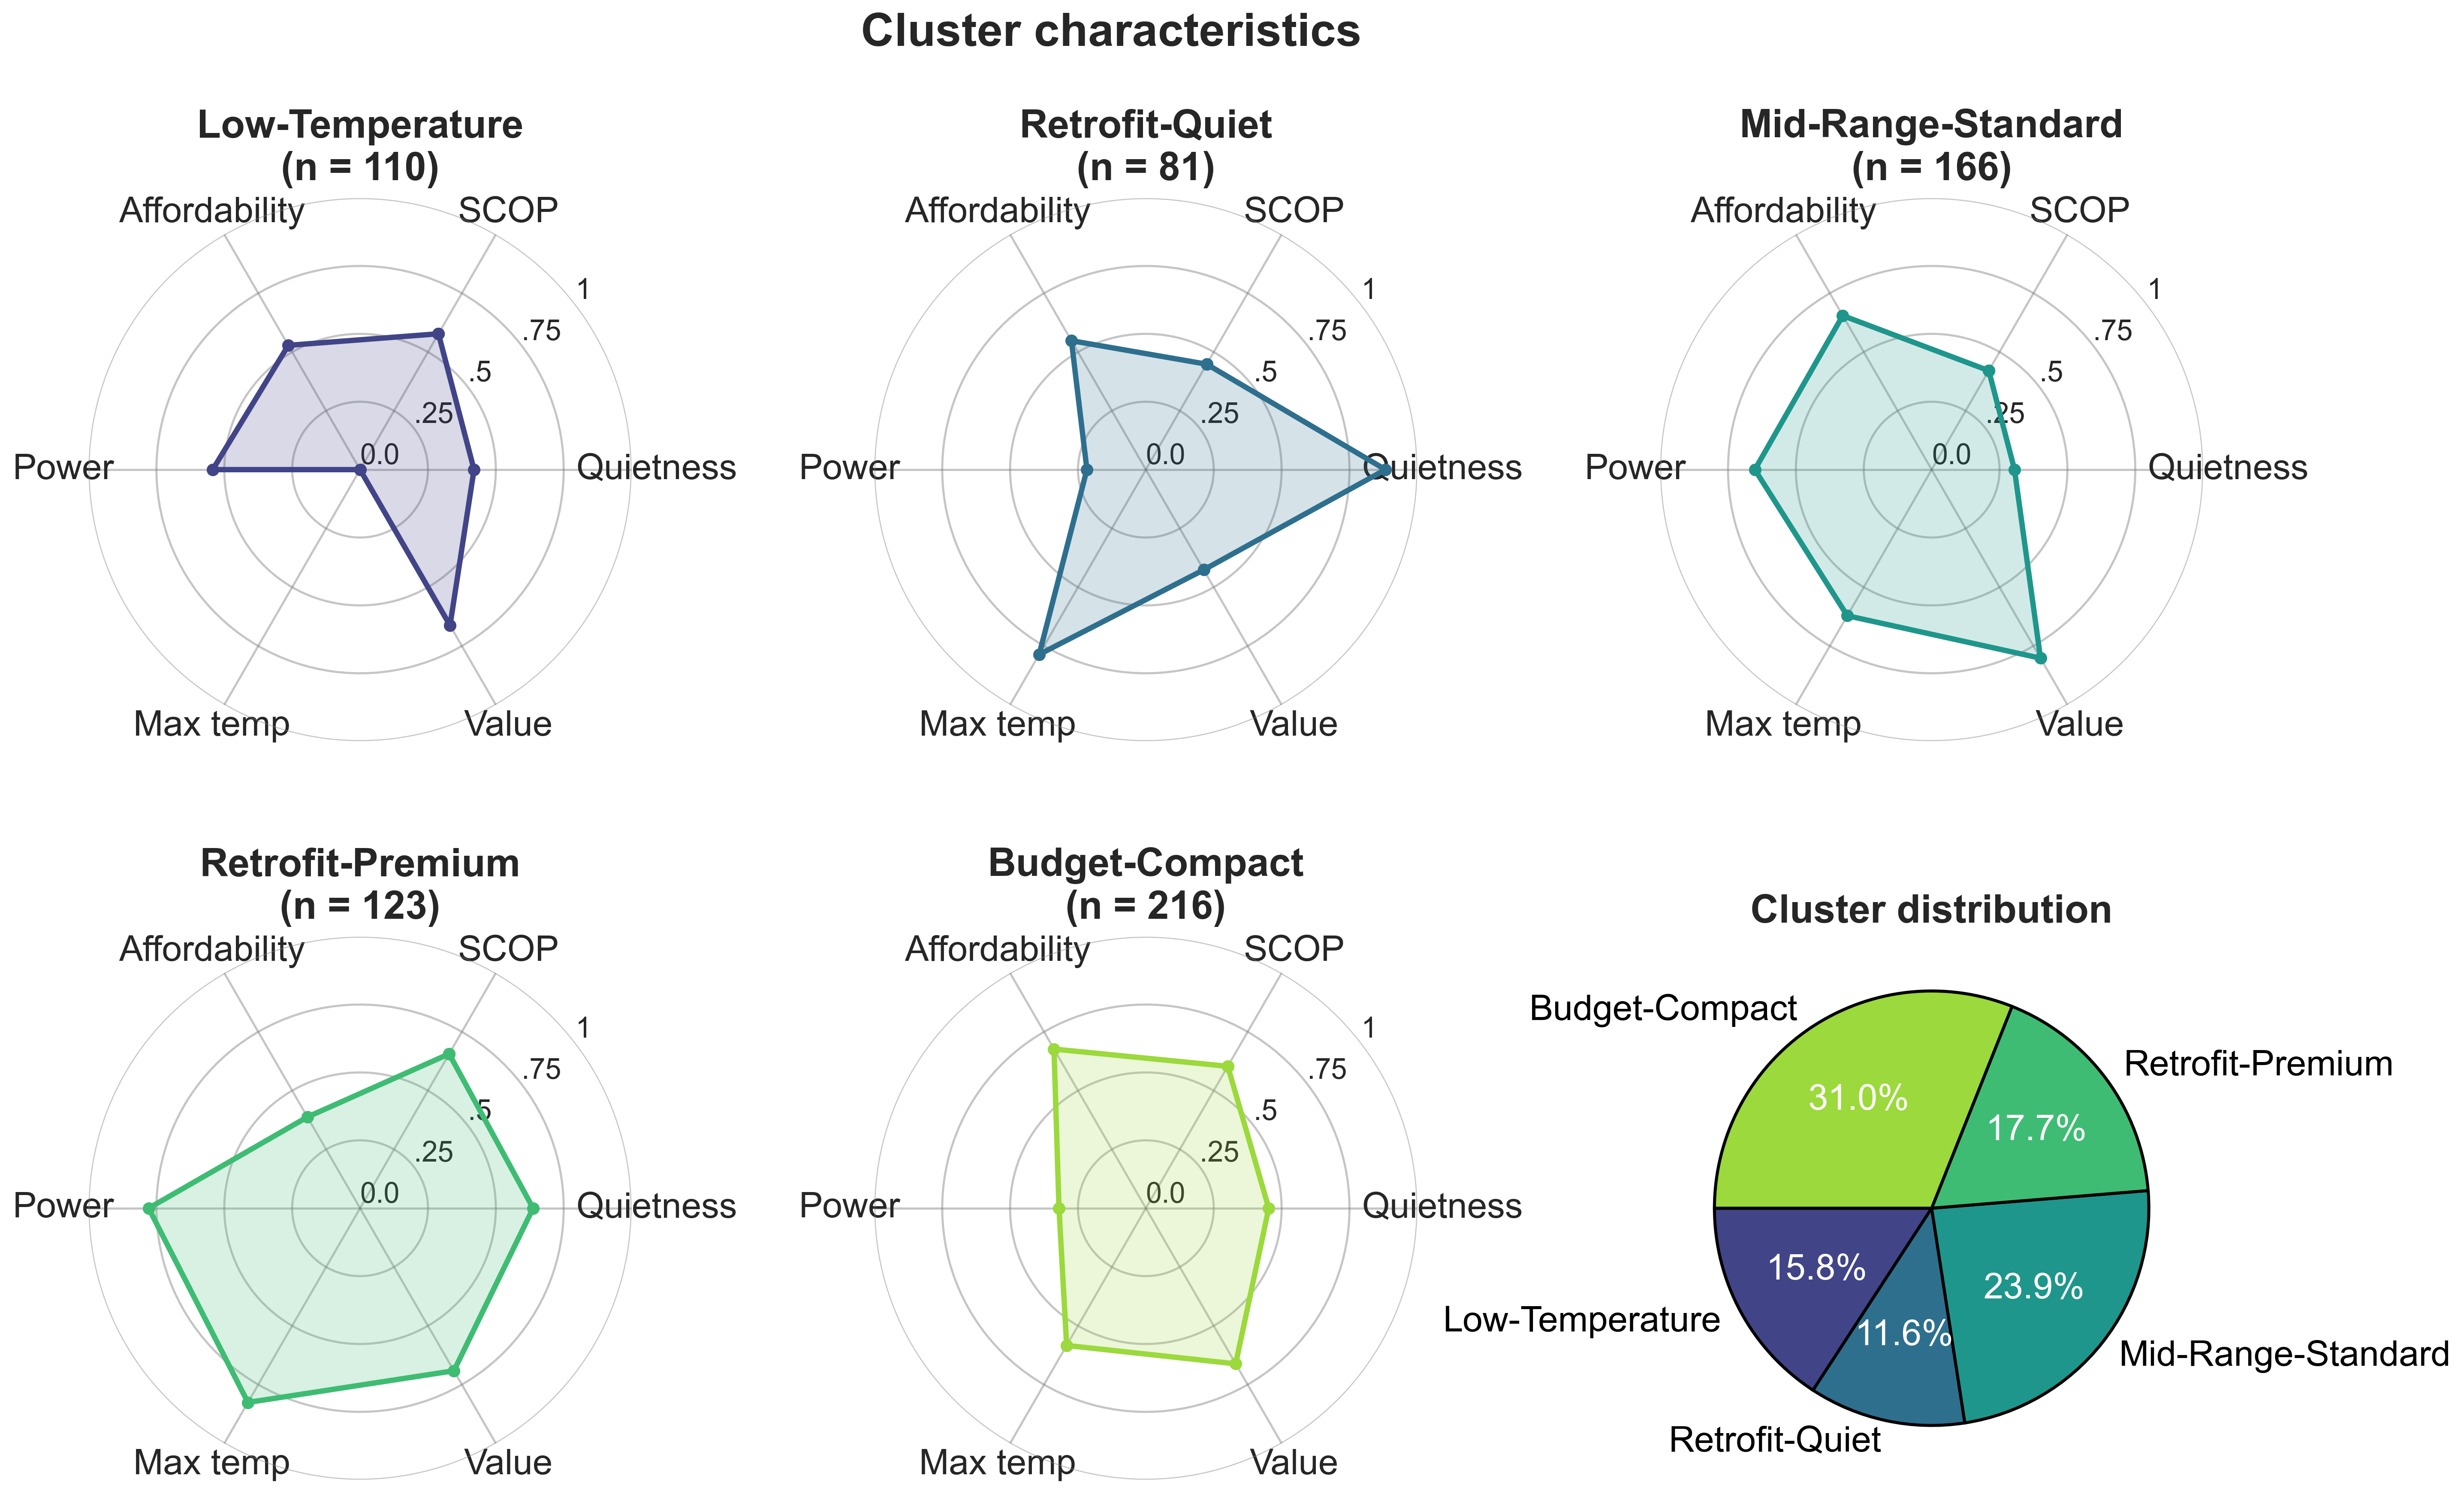

In [10]:
# Create visualizations (files are saved) and display them inline

method_label = f"K-means (Final k={selected_k})"
create_cluster_visualizations(df_final, X_scaled, feature_names, cluster_names_final, figures_dir, method_label)

# Derive the sanitized method directory name exactly as in module
safe_method_name = method_label.lower().replace('-', '_').replace(' ', '_').replace('(', '').replace(')', '').replace('=', '_')
method_dir = figures_dir / safe_method_name


image_files = [
    # 'pca_clusters.png',
    # 'feature_distributions_boxplot.png',
    # 'feature_distributions_violin.png',
    'cluster_characteristics.png',
    # 'price_vs_efficiency.png',
    # 'market_segments.png',
]

for img in image_files:
    path = method_dir / img
    display(Markdown(f"### {img.replace('_', ' ').replace('.png','').title()}"))
    display(Image(filename=str(path)))


In [11]:
# Create marketing analysis report and preview it

report_path = cmp.create_marketing_analysis_report(df_final, cluster_names_final, figures_dir)

print(report_path)
print('\n--- Report Preview ---\n')
with open(report_path, 'r', encoding='utf-8') as f:
    # Show the first ~200 lines for quick review
    for i, line in enumerate(f):
        if i > 200:
            print('... (truncated)')
            break
        print(line.rstrip())



Creating marketing analysis report...
Marketing analysis report saved to: reports\figures\cluster_market_personalities\marketing_analysis_report.txt
reports\figures\cluster_market_personalities\marketing_analysis_report.txt

--- Report Preview ---

HEAT PUMP MARKET PERSONALITY ANALYSIS

EXECUTIVE SUMMARY
--------------------
Total market analyzed: 696 heat pump products
Number of market segments identified: 5
Analysis based on performance and pricing characteristics

DETAILED MARKET SEGMENT ANALYSIS
-----------------------------------

1. LOW-TEMPERATURE
Market Share: 15.8% (110 products)
Value Share: 17.2% of total market value
Average Price: 9,690 EUR
Key Performance Indicators:
  - Average SCOP: 4.77
  - Average Noise: 56.8 dBA
  - Average Power: 8.6 kW
  - Average Max Temperature: 35°C
  - Price range: 3,829 - 17,499 EUR
Leading Manufacturers:
  -  DAIKIN Europe N.V.: 102 products (92.7%)
  -  WOLF GmbH: 6 products (5.5%)
  -  Johnson Controls-Hitachi AirConditioning Spain: 2 prod